# DNV-RP-C203 S-N and Miner fatigue screening

This example uses NeqSim's edition-aware `DnvRpC203FatigueDesignKernel` with an immutable stress spectrum and an externally controlled S-N curve. The numeric curve is deliberately labelled `PROJECT-CONTROLLED-DEMO`; it is teaching data, not a transcription of a DNV curve table.

> **Boundary:** this is a regression-backed `SCREENING` calculation, not a fatigue conformity assessment. Verify the licensed edition, curve/detail and environment selection, structural stress derivation, thickness and stress-concentration factors, load combinations, rainflow counting, inspection plan, and acceptance independently.

In [1]:
from pathlib import Path
import os
import sys
import jpype

ROOT = Path.cwd().resolve()
while not (ROOT / 'pom.xml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'pom.xml').exists(), 'Run this notebook from the NeqSim repository tree'

if not jpype.isJVMStarted():
    local_classpath = os.environ.get('NEQSIM_NOTEBOOK_CLASSPATH')
    if local_classpath:
        jpype.startJVM(classpath=local_classpath.split(os.pathsep), convertStrings=True)
    else:
        sys.path.insert(0, str(ROOT / 'devtools'))
        from neqsim_dev_setup import neqsim_init
        neqsim_init(project_root=ROOT, recompile=not (ROOT / 'target/classes').exists(), verbose=False)

from jpype import JClass
import pandas as pd
import matplotlib.pyplot as plt
print('Workspace kernel loaded:', ROOT)

Workspace kernel loaded: /workspace/scratch/de313162ffce/repo_c203


## 1. Controlled curve, spectrum, and factors

For each bin, the kernel applies $\Delta\sigma_{eff}=\Delta\sigma_{nom}\,SCF\,f_{th}\,f_{other}$, evaluates $\log_{10}N=\log_{10}A-m\log_{10}(\Delta\sigma_{eff})$, and sums $D=\sum n_i/N_i$. The design damage is `DFF × D`, and utilization divides that value by the supplied damage limit.

In [2]:
StandardType = JClass('neqsim.process.mechanicaldesign.designstandards.StandardType')
StandardEdition = JClass('neqsim.process.mechanicaldesign.designstandards.StandardEdition')
Kernel = JClass('neqsim.process.engineering.calculation.DnvRpC203FatigueDesignKernel')
Input = JClass('neqsim.process.engineering.calculation.DnvRpC203FatigueDesignKernel$Input')
SnCurve = JClass('neqsim.process.engineering.calculation.DnvRpC203FatigueDesignKernel$SnCurve')

edition = StandardEdition.defaultEdition(StandardType.DNV_RP_C203)
kernel = Kernel()
demo_curve = SnCurve.singleSlope('PROJECT-CONTROLLED-DEMO', 12.0, 3.0)

def run_case(scf=1.0, curve_verified=True, spectrum_verified=True):
    fatigue_input = (Input.builder(edition, 'Pipeline')
        .snCurve(demo_curve)
        .addStressBin('high range', 100.0, 1.0e5)
        .addStressBin('moderate range', 50.0, 2.0e5)
        .stressConcentrationFactor(scf)
        .thicknessCorrectionFactor(1.0)
        .otherStressRangeFactor(1.0)
        .designFatigueFactor(3.0)
        .minerDamageLimit(1.0)
        .assessedExposureYears(20.0)
        .curveDefinitionVerified(curve_verified)
        .stressSpectrumVerified(spectrum_verified)
        .build())
    return kernel.calculate(fatigue_input, None)

result = run_case()
assessment = result.getValue()
summary = pd.Series({
    'status': str(result.getStatus()),
    'edition': str(assessment.getStandardEdition()),
    'controlled curve id': str(assessment.getCurveIdentifier()),
    'raw Miner damage [-]': float(assessment.getRawMinerDamage()),
    'design Miner damage [-]': float(assessment.getDesignMinerDamage()),
    'damage utilization [-]': float(assessment.getDamageUtilization()),
    'within supplied limit': bool(assessment.isWithinDamageLimit()),
    'estimated design life [years]': float(assessment.getEstimatedDesignFatigueLifeYears()),
    'governing bin': str(assessment.getGoverningBinLabel()),
    'engineering approval required': bool(assessment.toMap().get('engineeringApprovalRequired')),
})
assert abs(float(assessment.getRawMinerDamage()) - 0.125) < 1e-12
assert abs(float(assessment.getDesignMinerDamage()) - 0.375) < 1e-12
summary.to_frame('screening result')

,screening result
status,CALCULATED_REVIEW_REQUIRED
edition,DNV-RP-C203 2024-10+AMD:2025-10
controlled curve id,PROJECT-CONTROLLED-DEMO
raw Miner damage [-],0.125
design Miner damage [-],0.375
damage utilization [-],0.375
within supplied limit,True
estimated design life [years],53.333333
governing bin,high range
engineering approval required,True


## 2. Damage contribution by stress-range bin

Miner damage is additive, so the contribution plot makes the governing portion of the supplied spectrum visible. A small number of high stress cycles can dominate because cycles to failure vary with stress raised to the S-N slope.

,spectrum bin,nominal stress [MPa],effective stress [MPa],cycles,cycles to failure,Miner damage [-]
0,high range,100.0,100.0,100000.0,1000000.0,0.100
1,moderate range,50.0,50.0,200000.0,8000000.0,0.025


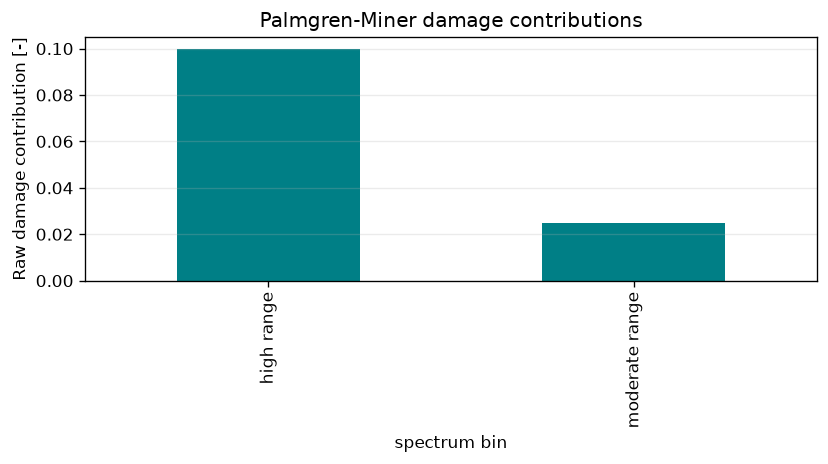

In [3]:
bins = pd.DataFrame([{
    'spectrum bin': str(item.getLabel()),
    'nominal stress [MPa]': float(item.getNominalStressRangeMPa()),
    'effective stress [MPa]': float(item.getEffectiveStressRangeMPa()),
    'cycles': float(item.getNumberOfCycles()),
    'cycles to failure': float(item.getCyclesToFailure()),
    'Miner damage [-]': float(item.getMinerDamage()),
} for item in assessment.getBins()])
display(bins)

ax = bins.plot.bar(x='spectrum bin', y='Miner damage [-]', legend=False, color='#007F86', figsize=(7, 4))
ax.set_title('Palmgren-Miner damage contributions')
ax.set_ylabel('Raw damage contribution [-]')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Factor identity and fail-closed evidence

For this single-slope demonstration with $m=3$, doubling the applied stress-range factor increases damage by $2^3=8$. The second check shows that a numerically complete input is still blocked when its curve source has not been verified.

In [4]:
factored = run_case(scf=2.0).getValue()
damage_ratio = float(factored.getRawMinerDamage() / assessment.getRawMinerDamage())
assert abs(damage_ratio - 8.0) < 1e-12

blocked = run_case(curve_verified=False)
blockers = [dict(item) for item in blocked.getReadiness().toMap().get('blockers')]
assert str(blocked.getStatus()) == 'BLOCKED'
assert blocked.getValue() is None
display(pd.Series({'SCF 2 / SCF 1 damage ratio': damage_ratio}).to_frame('identity'))
pd.DataFrame(blockers)[['code', 'message', 'requiredAction']]

,identity
SCF 2 / SCF 1 damage ratio,8.0


,code,message,requiredAction
0,C203_CURVE_NOT_VERIFIED,The supplied S-N parameters require verificati...,"Check curve identifier, environment, detail ca..."


## Interpretation and exercises

Use this result only as the arithmetic layer of a controlled fatigue workflow. The engineering record must identify where the curve, stress spectrum, SCFs, thickness/environmental corrections, design fatigue factor, damage limit, and exposure came from.

Try these extensions:

1. Add a low-stress, high-cycle bin and compare its damage contribution.
2. Change the design fatigue factor while keeping raw damage fixed; explain the utilization change.
3. Build a continuous bi-linear demonstration curve and test values on both sides of its transition.